# Scale assignment tests

In [11]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from scipy.stats import binomtest, ttest_rel, wilcoxon

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "scripts").is_dir()
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from scripts.reproducibility.real_scale_swap.aggregate_permutation_campaign import (
    load_campaign,
    linear_auc,
)

CAMPAIGN_ROOT = PROJECT_ROOT / "outputs/scale_swap_permutations"
campaign = load_campaign(CAMPAIGN_ROOT)

print("low/high curve shape:", campaign["low"].shape)
print("steps:", campaign["steps"][0], "to", campaign["steps"][-1])
print("datasets:", campaign["names"])

low/high curve shape: (15, 8, 86)
steps: 0 to 29999
datasets: ['electricity', 'traffic', 'solar_10_minutes', 'taxi_30min', 'wind_farms_without_missing', 'pedestrian_counts', 'kdd_cup_2018_without_missing', 'fred_md']


In [12]:
# AUC uses ordinary nMSE. Positive differences favor b=10.
auc_b1 = linear_auc(campaign["low"], campaign["steps"])
auc_b10 = linear_auc(campaign["high"], campaign["steps"])
differences = auc_b1 - auc_b10
percent_reductions = 100 * differences / auc_b1

assert differences.shape == (15, 8)
assert np.isfinite(differences).all()
assert np.all(differences != 0)
for dataset_differences in differences.T:
    assert len(np.unique(np.abs(dataset_differences))) == 15

In [13]:
def holm_adjust(p_values):
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running_max = 0.0
    for rank, index in enumerate(order):
        candidate = (len(p_values) - rank) * p_values[index]
        running_max = max(running_max, candidate)
        adjusted[index] = min(running_max, 1.0)
    return adjusted


# Per-dataset tests across assignment contexts.
wilcoxon_results = [
    wilcoxon(
        dataset_differences,
        alternative="greater",
        zero_method="wilcox",
        method="exact",
    )
    for dataset_differences in differences.T
]
wilcoxon_p = np.array([result.pvalue for result in wilcoxon_results])
wilcoxon_holm = holm_adjust(wilcoxon_p)

sign_results = [
    binomtest(
        int((dataset_differences > 0).sum()),
        n=len(dataset_differences),
        p=0.5,
        alternative="greater",
    )
    for dataset_differences in differences.T
]
sign_p = np.array([result.pvalue for result in sign_results])
sign_holm = holm_adjust(sign_p)

# General effect across datasets.
mean_auc_b1 = auc_b1.mean(axis=0)
mean_auc_b10 = auc_b10.mean(axis=0)
paired_t = ttest_rel(mean_auc_b1, mean_auc_b10, alternative="greater")

In [ ]:
results = pd.DataFrame(
    {
        "dataset": campaign["names"],
        "positive_pairs": (differences > 0).sum(axis=0),
        "median_auc_difference": np.median(differences, axis=0),
        "median_percent_reduction": np.median(percent_reductions, axis=0),
        "wilcoxon_W_plus": [result.statistic for result in wilcoxon_results],
        "wilcoxon_p": wilcoxon_p,
        "wilcoxon_holm_p": wilcoxon_holm,
        "sign_test_p": sign_p,
        "sign_test_holm_p": sign_holm,
    }
)
print("Primary general-effect paired t-test")
print(f"t(7) = {paired_t.statistic:.6f}")
print(f"one-sided p = {paired_t.pvalue:.6f}")
print(f"mean AUC difference = {(mean_auc_b1 - mean_auc_b10).mean():.6f}")
print()
print("Secondary per-dataset tests")
print(results.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

display(
    results.style.format(
        {
            "median_auc_difference": "{:.3f}",
            "median_percent_reduction": "{:.1f}%",
            "wilcoxon_p": "{:.5f}",
            "wilcoxon_holm_p": "{:.5f}",
            "sign_test_p": "{:.5f}",
            "sign_test_holm_p": "{:.5f}",
        }
    )
)

Primary general-effect paired t-test
t(7) = 2.013124
one-sided p = 0.041989
mean AUC difference = 0.693506

Secondary per-dataset tests
                     dataset  positive_pairs  median_auc_difference  median_percent_reduction  wilcoxon_W_plus  wilcoxon_p  wilcoxon_holm_p  sign_test_p  sign_test_holm_p
                 electricity              14               0.302364                 28.825780       118.000000    0.000092         0.000458     0.000488          0.002930
                     traffic              14               0.539081                 28.781258       119.000000    0.000061         0.000366     0.000488          0.002930
            solar_10_minutes              14               0.579533                 40.065530       116.000000    0.000214         0.000854     0.000488          0.002930
                  taxi_30min              15               0.978926                 33.649678       120.000000    0.000031         0.000244     0.000031          0.000244
  wind_fa

,dataset,positive_pairs,median_auc_difference,median_percent_reduction,wilcoxon_W_plus,wilcoxon_p,wilcoxon_holm_p,sign_test_p,sign_test_holm_p
0,electricity,14,0.302,28.8%,118.000000,0.00009,0.00046,0.00049,0.00293
1,traffic,14,0.539,28.8%,119.000000,0.00006,0.00037,0.00049,0.00293
2,solar_10_minutes,14,0.580,40.1%,116.000000,0.00021,0.00085,0.00049,0.00293
3,taxi_30min,15,0.979,33.6%,120.000000,0.00003,0.00024,0.00003,0.00024
4,wind_farms_without_missing,3,-0.281,-9.1%,10.000000,0.99899,0.99899,0.99631,0.99631
5,pedestrian_counts,11,0.215,21.3%,105.000000,0.00418,0.01254,0.05923,0.11847
6,kdd_cup_2018_without_missing,12,0.154,4.2%,105.000000,0.00418,0.01254,0.01758,0.05273
7,fred_md,15,2.679,52.7%,120.000000,0.00003,0.00024,0.00003,0.00024


Saved figure to /zfsauton2/home/istepka/ts-normalization/outputs/scale_swap_permutation_analysis/scale_swap_wilcoxon_differences.png


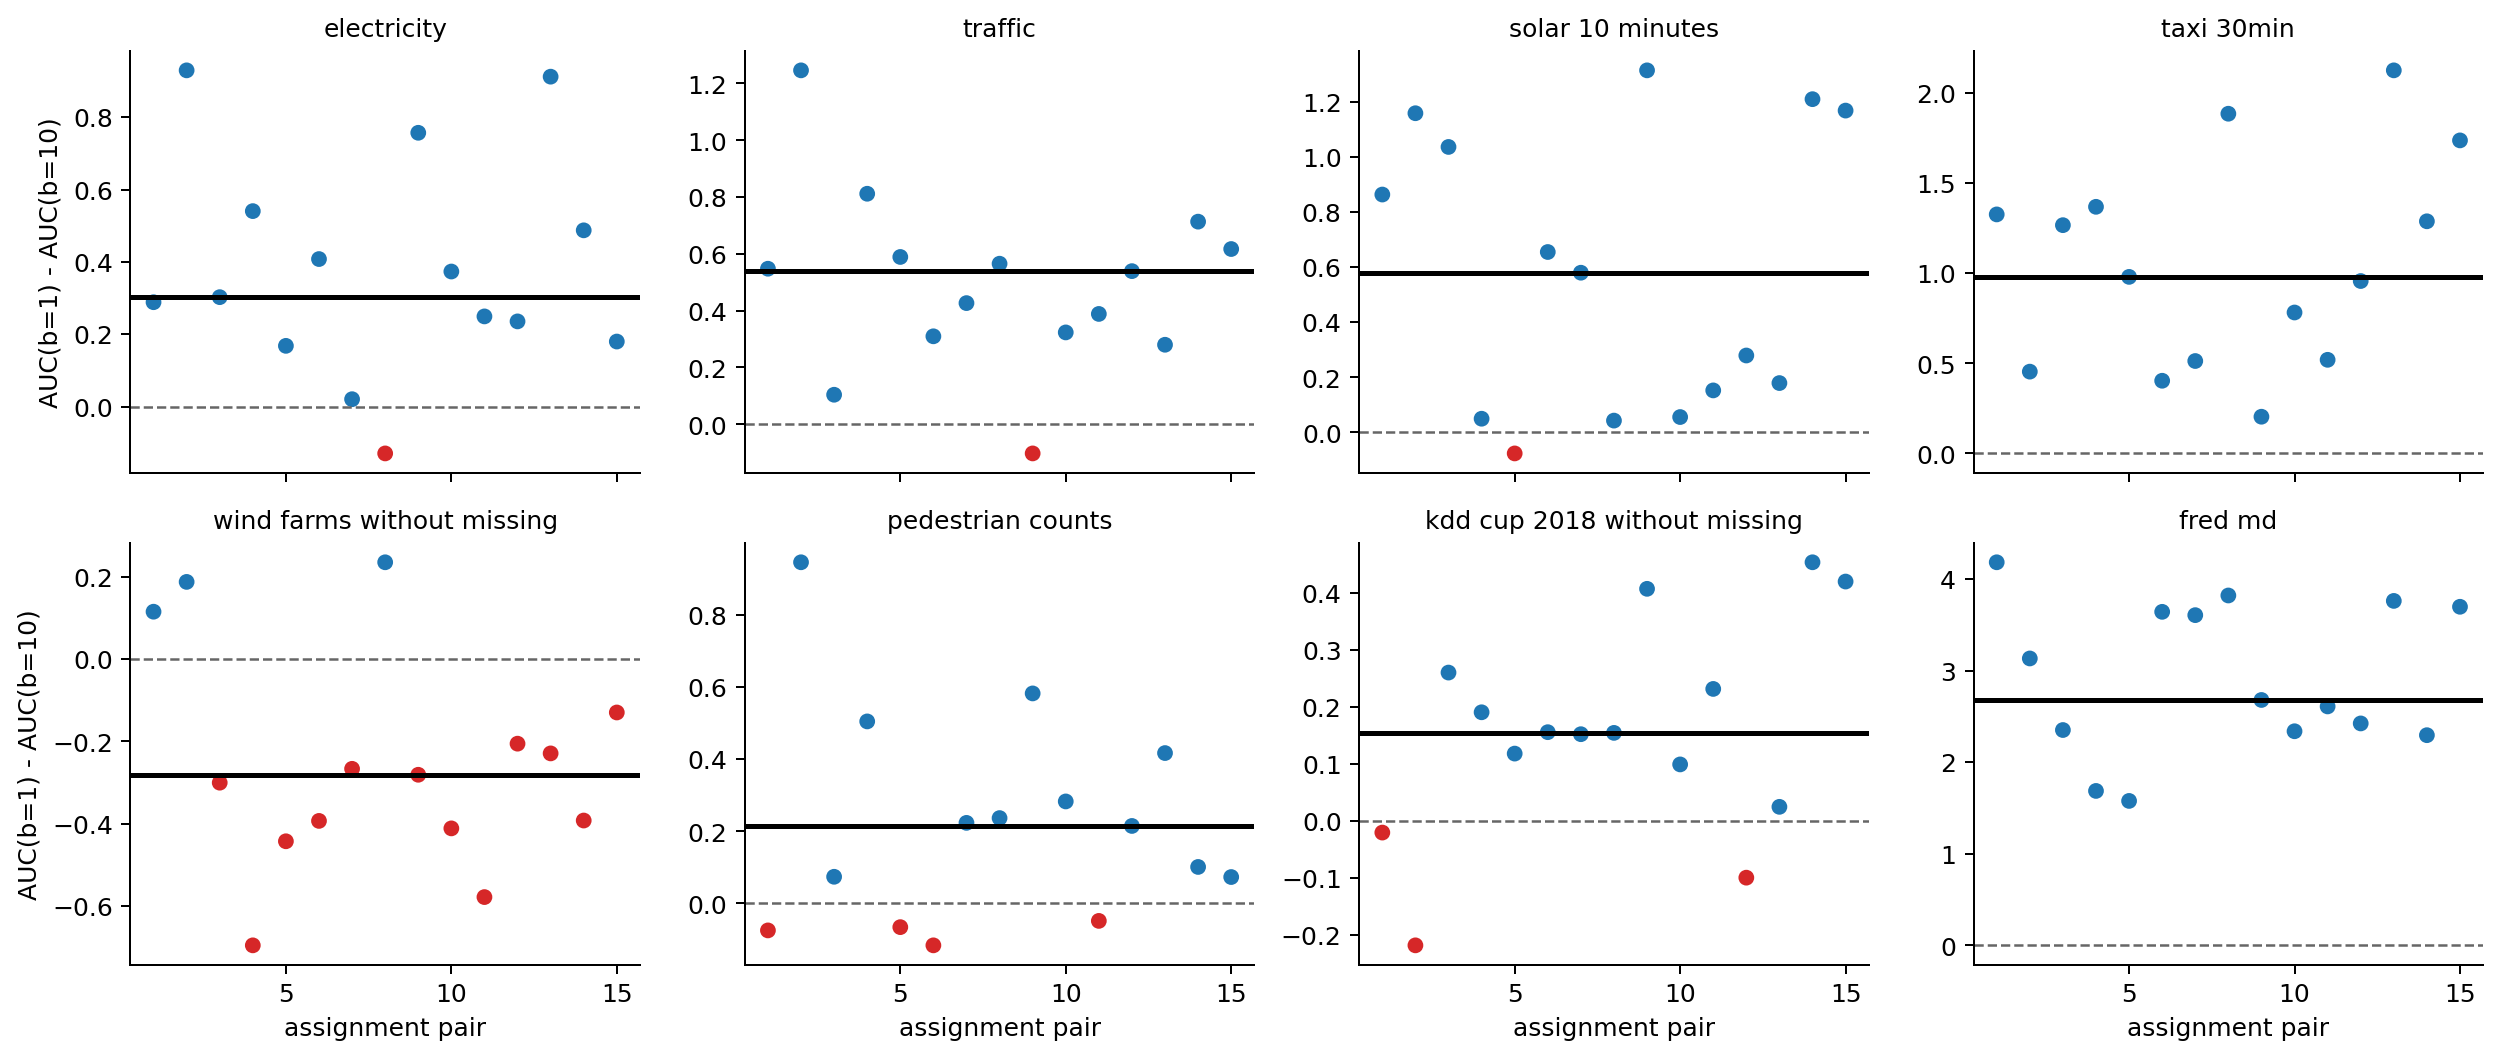

In [15]:
display_names = [name.replace("_", " ") for name in campaign["names"]]
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True)
pair_numbers = np.arange(1, 16)

for dataset, (ax, name) in enumerate(zip(axes.flat, display_names)):
    values = differences[:, dataset]
    colors = np.where(values > 0, "tab:blue", "tab:red")
    ax.axhline(0, color="0.4", linestyle="--", linewidth=1)
    ax.scatter(pair_numbers, values, color=colors, s=28)
    ax.axhline(np.median(values), color="black", linewidth=2)
    ax.set_title(name, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if dataset >= 4:
        ax.set_xlabel("assignment pair")
    if dataset % 4 == 0:
        ax.set_ylabel("AUC(b=1) - AUC(b=10)")

fig.tight_layout()
figure_path = PROJECT_ROOT / (
    "outputs/scale_swap_permutation_analysis/scale_swap_wilcoxon_differences.png"
)
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
print(f"Saved figure to {figure_path}")
plt.close(fig)
display(Image(filename=figure_path))